# Bank Innovation LSTM — Connor
Uses k-fold cross validation so every bank gets evaluated, including rare clusters.

In [3]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from bank_innovation.classification_nn import (
    load_clustered_data,
    encode_labels,
    scale_features,
    build_sequences,
    pad_sequence_sets,
    get_class_weights,
    build_lstm_model,
    build_gru_model,
    FEATURE_COLS,
)

/Users/connor/Desktop/Captstone/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Settings — change TIER here

In [4]:
TIER       = 'Small'   # 'Small', 'Medium', or 'Large'
N_FOLDS    = 5
EPOCHS     = 60
BATCH_SIZE = 32
MODEL_TYPE = 'GRU'     # 'LSTM' or 'GRU'
CSV_PATH   = 'data/bank_innovation_clustered_optimized.csv'

## 1. Load and encode data

In [62]:
df = load_clustered_data(csv_path=CSV_PATH, tier=TIER, drop_noise=True)
df, label_map, reverse_label_map = encode_labels(df)

all_banks = df['rssd9017'].unique()
print(f'Total banks in {TIER} tier: {len(all_banks)}')
print(f'Label map: {label_map}')

Filtered to tier: Small (37402 rows)
Dropped 2707 noise rows
Final data shape: (34695, 25)
Cluster counts:
innovation_cluster
0      325
1      427
2      366
3    33577
Name: count, dtype: int64
Label map: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3}
Number of classes: 4
Total banks in Small tier: 5629
Label map: {np.int64(0): 0, np.int64(1): 1, np.int64(2): 2, np.int64(3): 3}


## 2. K-Fold Cross Validation

Splits at the bank level — every bank gets into the test set exactly once.
This means even rare clusters (e.g. 24 observations) get properly evaluated
instead of landing in test only once or twice.

In [63]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

all_y_true = []
all_y_pred = []
fold_accuracies = []

for fold, (train_idx, test_idx) in enumerate(kf.split(all_banks)):
    print(f'\nFold {fold+1}/{N_FOLDS}')

    train_banks = all_banks[train_idx]
    test_banks  = all_banks[test_idx]

    train_df = df[df['rssd9017'].isin(train_banks)].copy()
    test_df  = df[df['rssd9017'].isin(test_banks)].copy()

    # Scale fit on train only
    train_df, test_df, _ = scale_features(train_df, test_df, FEATURE_COLS)

    # Build sequences — one per bank, label = last window cluster
    train_seqs, y_train, _ = build_sequences(train_df)
    test_seqs,  y_test,  _ = build_sequences(test_df)

    X_train, X_test, _ = pad_sequence_sets(train_seqs, test_seqs)
    class_weights = get_class_weights(y_train)

    # Build a fresh model each fold
    if MODEL_TYPE == 'LSTM':
        model = build_lstm_model(X_train.shape[1], X_train.shape[2], len(label_map))
    else:
        model = build_gru_model(X_train.shape[1], X_train.shape[2], len(label_map))

    model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        class_weight=class_weights,
        verbose=0,
    )

    y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
    acc = np.mean(y_pred == y_test)
    fold_accuracies.append(acc)

    print(f'  Accuracy: {acc:.3f}  |  Test banks: {len(y_test)}')

    all_y_true.extend(y_test.tolist())
    all_y_pred.extend(y_pred.tolist())

print(f'\nMean CV accuracy: {np.mean(fold_accuracies):.3f} (+/- {np.std(fold_accuracies):.3f})')


Fold 1/5
Built 4503 sequences
Sequence length range: 1 – 9
Built 1126 sequences
Sequence length range: 1 – 9
Padded to max length: 9
Class weights: {np.int32(0): np.float64(17.31923076923077), np.int32(1): np.float64(18.7625), np.int32(2): np.float64(18.157258064516128), np.int32(3): np.float64(0.2608317886932345)}
  Accuracy: 0.893  |  Test banks: 1126

Fold 2/5
Built 4503 sequences
Sequence length range: 1 – 9
Built 1126 sequences
Sequence length range: 1 – 9
Padded to max length: 9
Class weights: {np.int32(0): np.float64(16.55514705882353), np.int32(1): np.float64(19.40948275862069), np.int32(2): np.float64(17.31923076923077), np.int32(3): np.float64(0.26107374768089053)}
  Accuracy: 0.896  |  Test banks: 1126

Fold 3/5
Built 4503 sequences
Sequence length range: 1 – 9
Built 1126 sequences
Sequence length range: 1 – 9
Padded to max length: 9
Class weights: {np.int32(0): np.float64(17.86904761904762), np.int32(1): np.float64(20.102678571428573), np.int32(2): np.float64(17.3192307692

## 3. Aggregated classification report

In [64]:
all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

target_names = [str(reverse_label_map[i]) for i in sorted(reverse_label_map.keys())]

print(f'Aggregated Classification Report — {TIER} Banks ({MODEL_TYPE})')
print(f'All {N_FOLDS} folds combined — every bank evaluated exactly once')
print('=' * 65)
print(classification_report(all_y_true, all_y_pred, target_names=target_names))

Aggregated Classification Report — Small Banks (GRU)
All 5 folds combined — every bank evaluated exactly once
              precision    recall  f1-score   support

           0       0.22      0.59      0.32        82
           1       0.32      0.73      0.44        71
           2       0.16      0.53      0.24        80
           3       0.99      0.91      0.95      5396

    accuracy                           0.90      5629
   macro avg       0.42      0.69      0.49      5629
weighted avg       0.95      0.90      0.92      5629



## 4. Confusion matrix

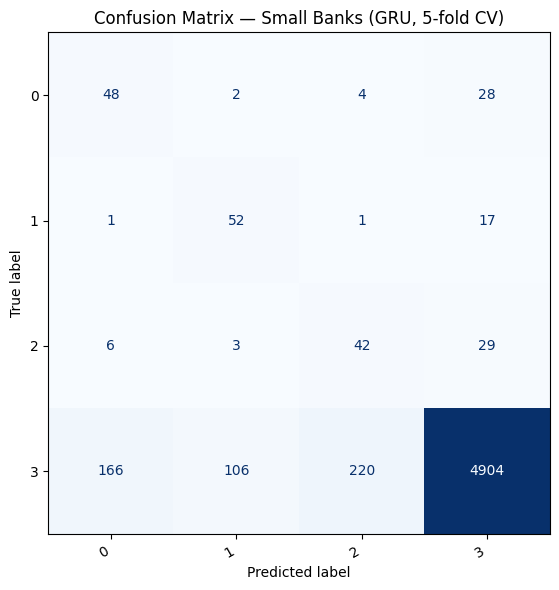

In [65]:
cm = confusion_matrix(all_y_true, all_y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {TIER} Banks ({MODEL_TYPE}, {N_FOLDS}-fold CV)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 5. Per-fold accuracy bar chart

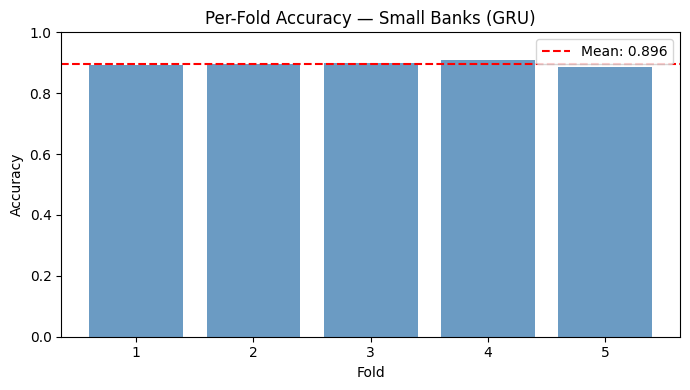

In [66]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(1, N_FOLDS+1), fold_accuracies, color='steelblue', alpha=0.8)
ax.axhline(np.mean(fold_accuracies), color='red', linestyle='--',
           label=f'Mean: {np.mean(fold_accuracies):.3f}')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_title(f'Per-Fold Accuracy — {TIER} Banks ({MODEL_TYPE})')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 6. LSTM vs GRU comparison
Runs both models through the same k-fold setup and compares.

In [67]:
results = {}

for model_type in ['LSTM', 'GRU']:
    fold_accs = []
    y_true_all, y_pred_all = [], []

    for fold, (train_idx, test_idx) in enumerate(kf.split(all_banks)):
        train_banks = all_banks[train_idx]
        test_banks  = all_banks[test_idx]

        train_df = df[df['rssd9017'].isin(train_banks)].copy()
        test_df  = df[df['rssd9017'].isin(test_banks)].copy()

        train_df, test_df, _ = scale_features(train_df, test_df, FEATURE_COLS)
        train_seqs, y_train, _ = build_sequences(train_df)
        test_seqs,  y_test,  _ = build_sequences(test_df)
        X_train, X_test, _ = pad_sequence_sets(train_seqs, test_seqs)
        cw = get_class_weights(y_train)

        if model_type == 'LSTM':
            m = build_lstm_model(X_train.shape[1], X_train.shape[2], len(label_map))
        else:
            m = build_gru_model(X_train.shape[1], X_train.shape[2], len(label_map))

        m.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE,
              class_weight=cw, verbose=0)

        y_pred = np.argmax(m.predict(X_test, verbose=0), axis=1)
        fold_accs.append(np.mean(y_pred == y_test))
        y_true_all.extend(y_test.tolist())
        y_pred_all.extend(y_pred.tolist())

    results[model_type] = {
        'mean_acc': np.mean(fold_accs),
        'std_acc':  np.std(fold_accs),
        'fold_accs': fold_accs,
    }
    print(f'{model_type}: {np.mean(fold_accs):.3f} (+/- {np.std(fold_accs):.3f})')

print(f'\nWinner: {max(results, key=lambda m: results[m]["mean_acc"])}')

Built 4503 sequences
Sequence length range: 1 – 9
Built 1126 sequences
Sequence length range: 1 – 9
Padded to max length: 9
Class weights: {np.int32(0): np.float64(17.31923076923077), np.int32(1): np.float64(18.7625), np.int32(2): np.float64(18.157258064516128), np.int32(3): np.float64(0.2608317886932345)}
Built 4503 sequences
Sequence length range: 1 – 9
Built 1126 sequences
Sequence length range: 1 – 9
Padded to max length: 9
Class weights: {np.int32(0): np.float64(16.55514705882353), np.int32(1): np.float64(19.40948275862069), np.int32(2): np.float64(17.31923076923077), np.int32(3): np.float64(0.26107374768089053)}
Built 4503 sequences
Sequence length range: 1 – 9
Built 1126 sequences
Sequence length range: 1 – 9
Padded to max length: 9
Class weights: {np.int32(0): np.float64(17.86904761904762), np.int32(1): np.float64(20.102678571428573), np.int32(2): np.float64(17.31923076923077), np.int32(3): np.float64(0.26065061356795555)}
Built 4503 sequences
Sequence length range: 1 – 9
Built

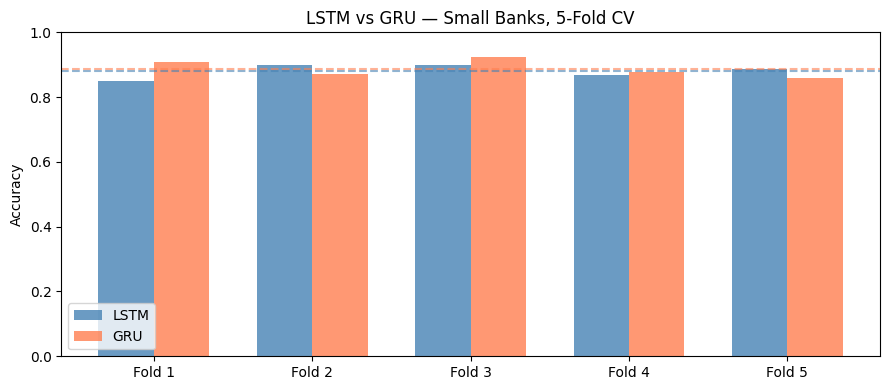

In [68]:
x = np.arange(N_FOLDS)
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width/2, results['LSTM']['fold_accs'], width, label='LSTM', color='steelblue', alpha=0.8)
ax.bar(x + width/2, results['GRU']['fold_accs'],  width, label='GRU',  color='coral',     alpha=0.8)
ax.axhline(results['LSTM']['mean_acc'], color='steelblue', linestyle='--', alpha=0.6)
ax.axhline(results['GRU']['mean_acc'],  color='coral',     linestyle='--', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.set_ylabel('Accuracy')
ax.set_title(f'LSTM vs GRU — {TIER} Banks, {N_FOLDS}-Fold CV')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Cluster Trajectory Interpretation
What patterns did the GRU learn? Three plots that show the signal the model picks up on:
1. Average change score per cluster per year window
2. Cluster fingerprint heatmap
3. Cluster population over time (COVID impact)

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load clustered data — uses same TIER variable set at top of notebook
df_plot = pd.read_csv(CSV_PATH)
df_plot = df_plot[
    (df_plot['bank_tier'] == TIER) &
    (df_plot['innovation_cluster'] != -1)
].copy()

# Key ratios that best separate the Medium clusters
KEY_RATIOS = [
    'nontrans_deposits_pct_change',
    'nib_deposit_ratio_change',
    'occupancy_intensity_change',
    'roa_change',
    'chargeoff_rate_change',
]

RATIO_LABELS = {
    'nontrans_deposits_pct_change': 'Non-Trans Deposits Change (%)',
    'nib_deposit_ratio_change':     'NIB Deposit Ratio Change (%)',
    'occupancy_intensity_change':   'Occupancy Intensity Change',
    'roa_change':                   'ROA Change',
    'chargeoff_rate_change':        'Charge-off Rate Change',
}

# Automatically use whatever clusters exist in the data for this tier
CLUSTER_ORDER = [
    c for c in [
        # Medium
        'Branch Expanders', 'Deposit Restructurers', 'Deposit Transformers',
        'Relationship Builders',
        # Small
        'Rapid Capitalizers', 'Funding Diversifiers', 'Stressed Performers',
        # Large
        'Branch Consolidators', 'Deposit Gatherers', 'Digital Retreaters',
        # All tiers
        'Steady Operators',
    ]
    if c in df_plot['cluster_name'].unique()
]

CLUSTER_COLORS = {
    # Medium
    'Branch Expanders':      '#2196F3',
    'Deposit Restructurers': '#F44336',
    'Deposit Transformers':  '#FF9800',
    'Relationship Builders': '#9C27B0',
    # Small
    'Rapid Capitalizers':    '#4CAF50',
    'Funding Diversifiers':  '#00BCD4',
    'Stressed Performers':   '#E91E63',
    # Large
    'Branch Consolidators':  '#795548',
    'Deposit Gatherers':     '#FF5722',
    'Digital Retreaters':    '#607D8B',
    # All
    'Steady Operators':      '#9E9E9E',
}

print('Clusters in plot:', CLUSTER_ORDER)
print('Data loaded:', df_plot.shape)
print('Clusters:', df_plot['cluster_name'].value_counts().to_dict())

Clusters in plot: ['Rapid Capitalizers', 'Funding Diversifiers', 'Stressed Performers', 'Steady Operators']
Data loaded: (34695, 31)
Clusters: {'Stressed Performers': 33577, 'Funding Diversifiers': 427, 'Steady Operators': 366, 'Rapid Capitalizers': 325}


### Plot 1: Average trajectory per cluster over time
Each line = one cluster. Shows which ratios define each cluster and when the signal appears.

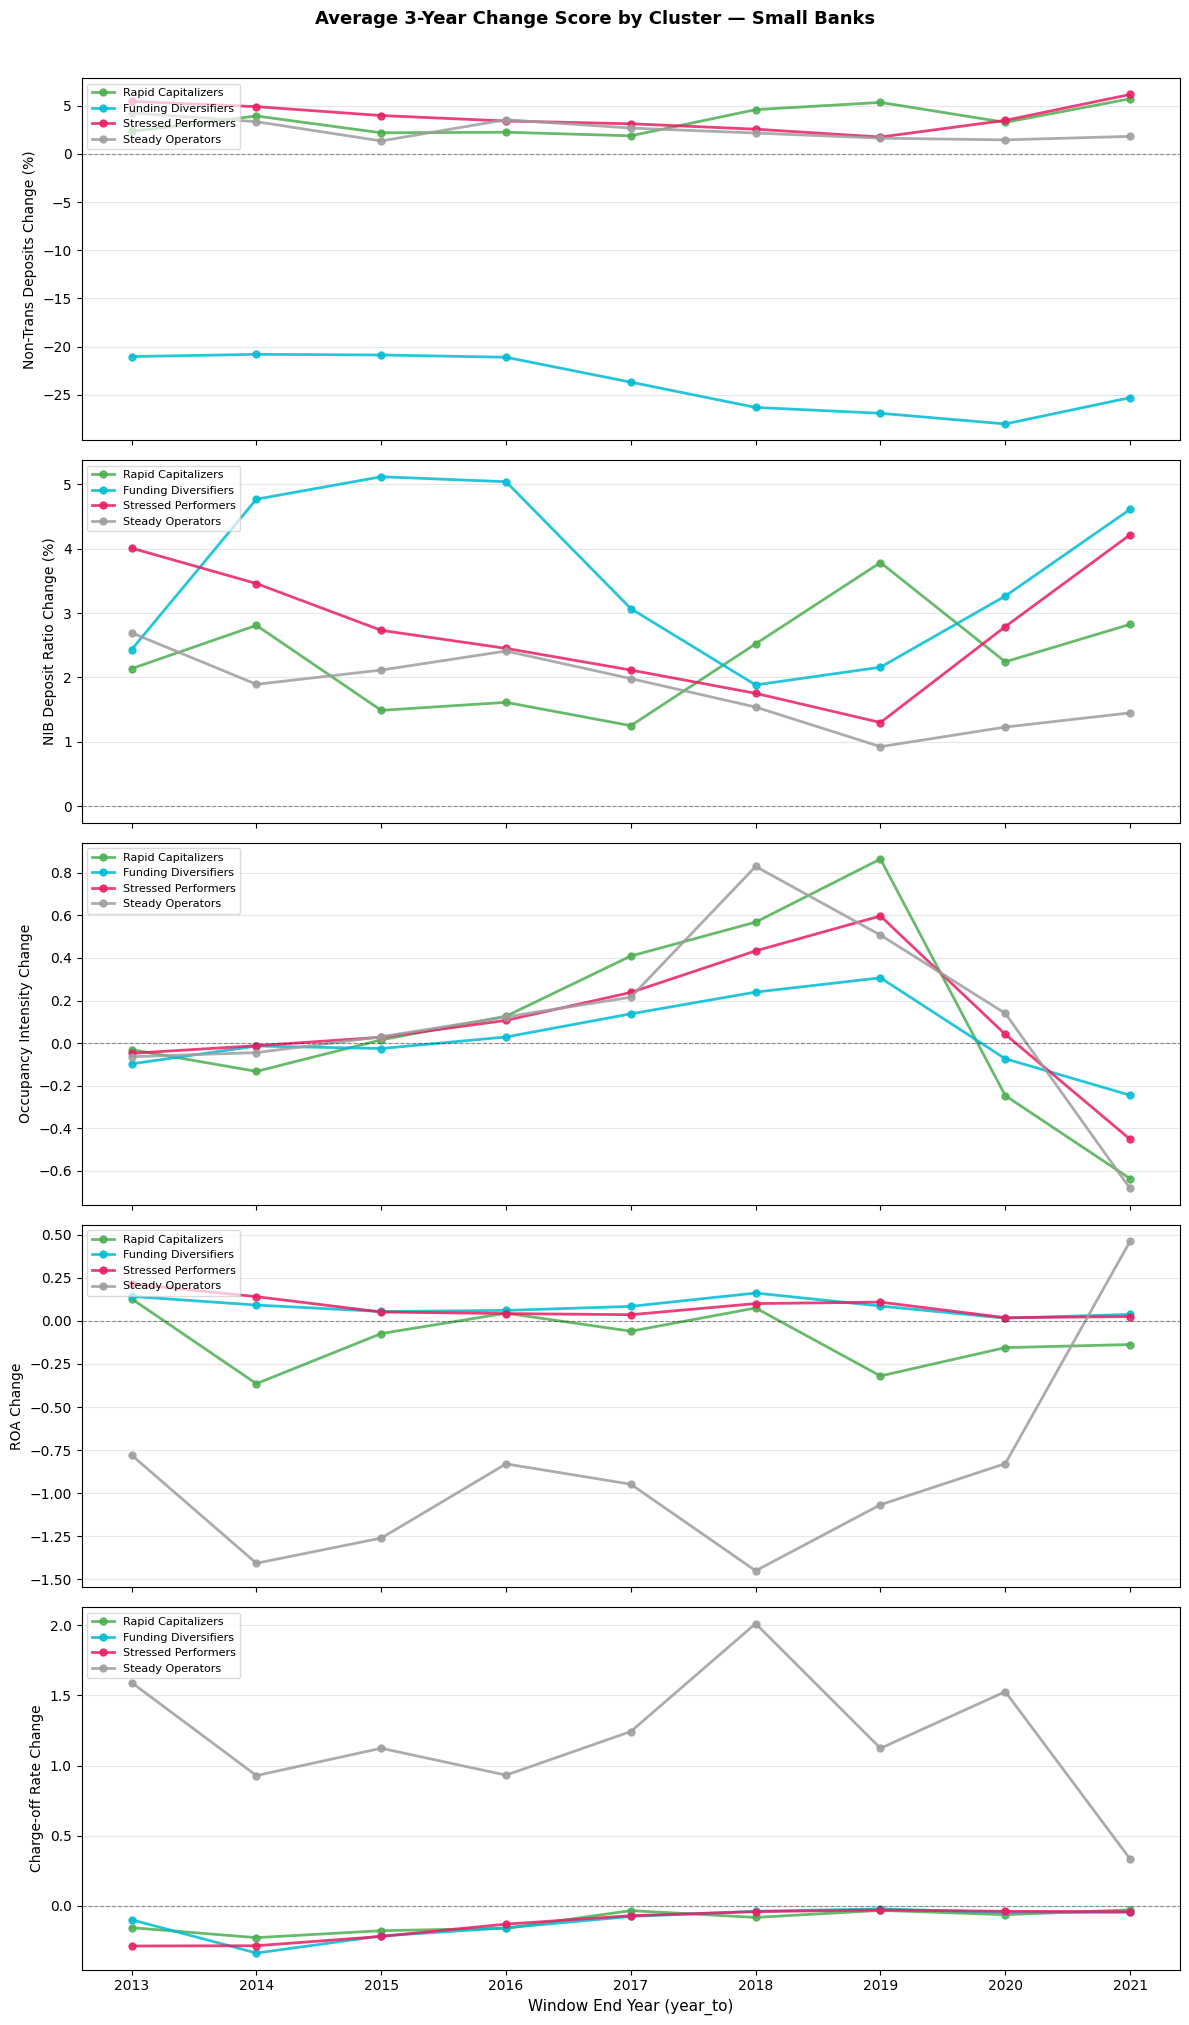

Saved: data/Small_cluster_trajectories.png


In [11]:
fig, axes = plt.subplots(len(KEY_RATIOS), 1, figsize=(12, 4 * len(KEY_RATIOS)), sharex=True)

for ax, ratio in zip(axes, KEY_RATIOS):
    for cluster_name in CLUSTER_ORDER:
        cluster_df = df_plot[df_plot['cluster_name'] == cluster_name]
        if cluster_df.empty:
            continue
        trajectory = (
            cluster_df.groupby('year_to')[ratio]
            .mean().reset_index().sort_values('year_to')
        )
        ax.plot(
            trajectory['year_to'], trajectory[ratio],
            marker='o', linewidth=2, markersize=5,
            label=cluster_name,
            color=CLUSTER_COLORS.get(cluster_name, 'black'),
            alpha=0.85,
        )
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
    ax.set_ylabel(RATIO_LABELS[ratio], fontsize=10)
    ax.legend(loc='upper left', fontsize=8, framealpha=0.7)
    ax.grid(axis='y', alpha=0.3)

axes[-1].set_xlabel('Window End Year (year_to)', fontsize=11)
fig.suptitle(f'Average 3-Year Change Score by Cluster — {TIER} Banks',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'data/{TIER}_cluster_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: data/{TIER}_cluster_trajectories.png')

### Plot 2: Cluster fingerprint heatmap
Which features most strongly define each cluster? Red = increase, blue = decrease.

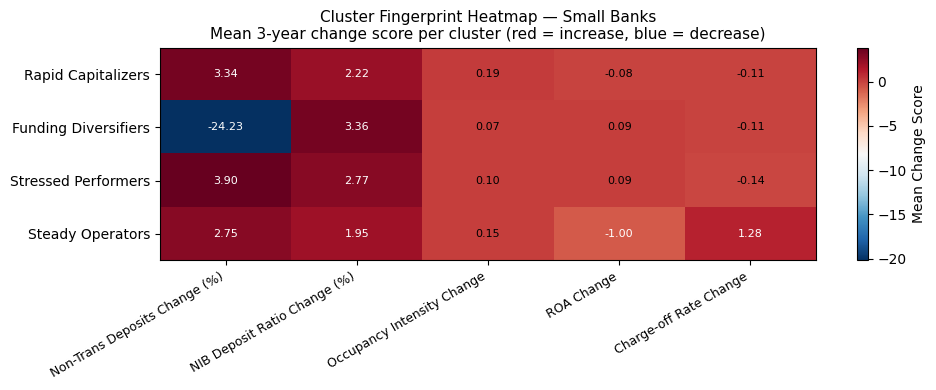

Saved: data/Small_cluster_heatmap.png


In [12]:
heatmap_data = (
    df_plot.groupby('cluster_name')[KEY_RATIOS]
    .mean()
    .reindex([c for c in CLUSTER_ORDER if c in df_plot['cluster_name'].unique()])
)
# Clip extremes for visual clarity
heatmap_clipped = heatmap_data.clip(
    lower=heatmap_data.quantile(0.05),
    upper=heatmap_data.quantile(0.95),
    axis=1,
)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heatmap_clipped.values, aspect='auto', cmap='RdBu_r')

ax.set_xticks(range(len(KEY_RATIOS)))
ax.set_xticklabels([RATIO_LABELS[r] for r in KEY_RATIOS], rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(heatmap_clipped)))
ax.set_yticklabels(heatmap_clipped.index, fontsize=10)

for i in range(len(heatmap_clipped)):
    for j in range(len(KEY_RATIOS)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(heatmap_clipped.values[i, j]) > 0.5 else 'black')

plt.colorbar(im, ax=ax, label='Mean Change Score')
ax.set_title(
    f'Cluster Fingerprint Heatmap — {TIER} Banks\n'
    'Mean 3-year change score per cluster (red = increase, blue = decrease)',
    fontsize=11
)
plt.tight_layout()
plt.savefig(f'data/{TIER}_cluster_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: data/{TIER}_cluster_heatmap.png')

### Plot 3: Cluster population over time
How many banks were in each cluster per year window? Shows COVID impact clearly.

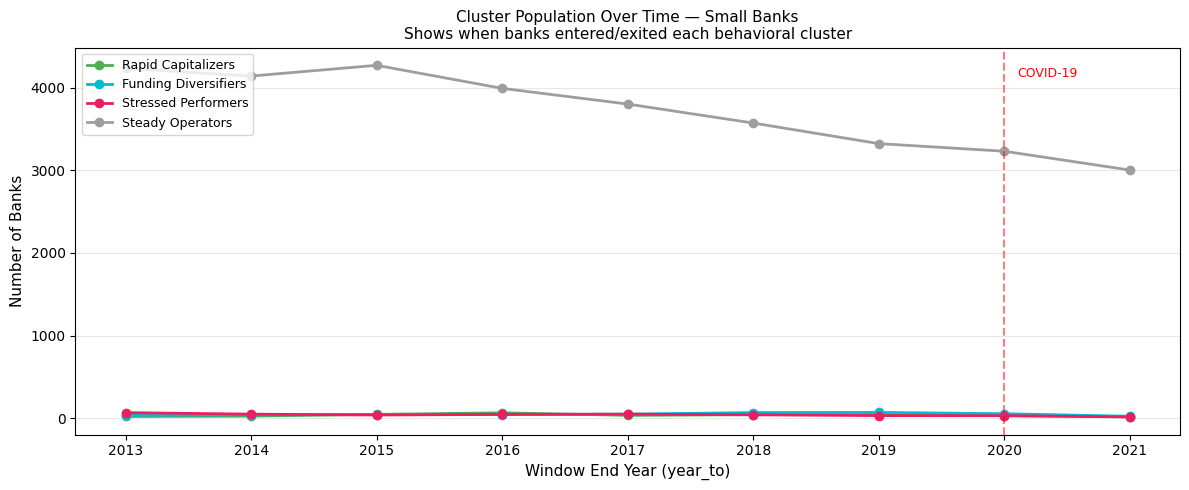

Saved: data/Small_cluster_counts_over_time.png


In [16]:
counts = df_plot.groupby(['year_to', 'cluster_name']).size().reset_index(name='count')

fig, ax = plt.subplots(figsize=(12, 5))

for cluster_name in CLUSTER_ORDER:
    cdf = counts[counts['cluster_name'] == cluster_name].sort_values('year_to')
    if cdf.empty:
        continue
    ax.plot(
        cdf['year_to'], cdf['count'],
        marker='o', linewidth=2, markersize=6,
        label=cluster_name,
        color=CLUSTER_COLORS.get(cluster_name, 'black'),
    )

# Mark COVID year
ax.axvline(2020, color='red', linestyle='--', alpha=0.5, linewidth=1.5)
ax.text(2020.1, ax.get_ylim()[1] * 0.92, 'COVID-19', color='red', fontsize=9)
ax.set_xlabel('Window End Year (year_to)', fontsize=11)
ax.set_ylabel('Number of Banks', fontsize=11)
ax.set_title(
    f'Cluster Population Over Time — {TIER} Banks\n'
    'Shows when banks entered/exited each behavioral cluster',
    fontsize=11
)
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'data/{TIER}_cluster_counts_over_time.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: data/{TIER}_cluster_counts_over_time.png')

In [15]:
# Fix Small tier cluster name mismatch
name_fix = {
    'Steady Operators': 'Stressed Performers',
    'Stressed Performers': 'Steady Operators',
}

df_plot = df_plot_raw[
    (df_plot_raw['bank_tier'] == TIER) &
    (df_plot_raw['innovation_cluster'] != -1)
].copy()

# Verify
print(df_plot_raw[df_plot_raw['bank_tier'] == 'Small'].groupby(['innovation_cluster', 'cluster_name']).size())

innovation_cluster  cluster_name        
-1                  Noise                    2707
 0                  Rapid Capitalizers        325
 1                  Funding Diversifiers      427
 2                  Stressed Performers       366
 3                  Steady Operators        33577
dtype: int64


In [18]:
# Split one train/test set for visualization
from sklearn.model_selection import train_test_split

all_banks = df['rssd9017'].unique()
train_banks, test_banks = train_test_split(all_banks, test_size=0.2, random_state=42)

train_df = df[df['rssd9017'].isin(train_banks)].copy()
test_df  = df[df['rssd9017'].isin(test_banks)].copy()

train_df, test_df, _ = scale_features(train_df, test_df, FEATURE_COLS)
train_seqs, y_train, _ = build_sequences(train_df)
test_seqs,  y_test,  _ = build_sequences(test_df)
X_train, X_test, _ = pad_sequence_sets(train_seqs, test_seqs)
cw = get_class_weights(y_train)

# Train final GRU
final_model = build_gru_model(X_train.shape[1], X_train.shape[2], len(label_map))
history = final_model.fit(
    X_train, y_train,
    epochs=60, batch_size=32,
    validation_data=(X_test, y_test),
    class_weight=cw, verbose=0,
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation', color='coral')
axes[0].set_title('GRU Accuracy — Medium Banks')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation', color='coral')
axes[1].set_title('GRU Loss — Medium Banks')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('data/Medium_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'df' is not defined

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(final_model.predict(X_test, verbose=0), axis=1)
target_names = [str(reverse_label_map[i]) for i in sorted(reverse_label_map.keys())]

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Medium Banks (GRU)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('data/Medium_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'final_model' is not defined